In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
df = pd.read_csv("insurance_data.csv")
print(df.shape)
df.info


(58592, 41)


<bound method DataFrame.info of        policy_id  subscription_length  vehicle_age  customer_age region_code  \
0      POL045360                  9.3          1.2            41          C8   
1      POL016745                  8.2          1.8            35          C2   
2      POL007194                  9.5          0.2            44          C8   
3      POL018146                  5.2          0.4            44         C10   
4      POL049011                 10.1          1.0            56         C13   
...          ...                  ...          ...           ...         ...   
58587  POL019269                 10.6          2.6            48          C5   
58588  POL001254                  2.3          2.2            37          C3   
58589  POL019859                  6.6          2.2            35          C8   
58590  POL014061                  4.1          3.6            44          C8   
58591  POL054184                  3.1          0.4            49         C12   

       

In [2]:
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


In [3]:
df.describe(include='all')

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
count,58592,58592.000000,58592.000000,58592.000000,58592,58592.000000,58592,58592,58592,58592,...,58592,58592,58592,58592,58592,58592,58592,58592,58592.000000,58592.000000
unique,58592,NaN,NaN,NaN,22,NaN,6,11,3,9,...,2,2,2,2,2,2,2,2,NaN,NaN
top,POL045360,NaN,NaN,NaN,C8,NaN,B2,M1,Petrol,113Nm@4400rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,NaN,NaN
freq,1,NaN,NaN,NaN,13654,NaN,18314,14948,20532,17796,...,32177,42435,42435,57383,34291,36309,42435,58229,NaN,NaN
mean,NaN,6.111688,1.388473,44.823935,NaN,18826.858667,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.759950,0.063968
std,NaN,4.142790,1.134413,6.935604,NaN,17660.174792,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.389576,0.244698
min,NaN,0.000000,0.000000,35.000000,NaN,290.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,NaN,2.100000,0.400000,39.000000,NaN,6112.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
50%,NaN,5.700000,1.200000,44.000000,NaN,8794.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000
75%,NaN,10.400000,2.200000,49.000000,NaN,27003.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,0.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   subscription_length               58592 non-null  float64
 2   vehicle_age                       58592 non-null  float64
 3   customer_age                      58592 non-null  int64  
 4   region_code                       58592 non-null  object 
 5   region_density                    58592 non-null  int64  
 6   segment                           58592 non-null  object 
 7   model                             58592 non-null  object 
 8   fuel_type                         58592 non-null  object 
 9   max_torque                        58592 non-null  object 
 10  max_power                         58592 non-null  object 
 11  engine_type                       58592 non-null  object 
 12  airb

In [5]:
df.isnull().sum()

policy_id                           0
subscription_length                 0
vehicle_age                         0
customer_age                        0
region_code                         0
region_density                      0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
steering_type                       0
turning_radius                      0
length                              0
width                               0
gross_weight

In [6]:
df.nunique()

policy_id                           58592
subscription_length                   140
vehicle_age                            49
customer_age                           41
region_code                            22
region_density                         22
segment                                 6
model                                  11
fuel_type                               3
max_torque                              9
max_power                               9
engine_type                            11
airbags                                 3
is_esc                                  2
is_adjustable_steering                  2
is_tpms                                 2
is_parking_sensors                      2
is_parking_camera                       2
rear_brakes_type                        2
displacement                            9
cylinder                                2
transmission_type                       2
steering_type                           3
turning_radius                    

# Question 1
Classify features into qualitative and quantitative
---

**Quantitative Features**

1. subscription_length
2. vehicle_age
3. customer_age
4. region_code (if numeric code; could be categorical, but usually numeric)
5. region_density (if numeric density, e.g., people/km²)
6. max_torque
7. max_power
8. displacement
9. turning_radius
10. length
11. width
12. gross_weight
13. ncap_rating

---

**Qualitative Features**

1. policy_id (identifier)
2. segment
3. model
4. fuel_type
5. engine_type
6. airbags
7. is_esc
8. is_adjustable_steering
9. is_tpms
10. is_parking_sensors
11. is_parking_camera
12. rear_brakes_type
13. cylinder
14. transmission_type
15. steering_type
16. is_front_fog_lights
17. is_rear_window_wiper
18. is_rear_window_washer
19. is_rear_window_defogger
20. is_brake_assist
21. is_power_door_locks
22. is_central_locking
23. is_power_steering
24. is_driver_seat_height_adjustable
25. is_day_night_rear_view_mirror
26. is_ecw
27. is_speed_alert
28. claim_status

---



# Question 2
Classify features into 4 levels
---
**Nominal (categorical, no order)**
* policy_id
* segment
* model
* fuel_type
* engine_type
* airbags
* is_esc
* is_adjustable_steering
* is_tpms
* is_parking_sensors
* is_parking_camera
* rear_brakes_type
* cylinder
* transmission_type
* steering_type
* is_front_fog_lights
* is_rear_window_wiper
* is_rear_window_washer
* is_rear_window_defogger
* is_brake_assist
* is_power_door_locks
* is_central_locking
* is_power_steering
* is_driver_seat_height_adjustable
* is_day_night_rear_view_mirror
* is_ecw
* is_speed_alert
* claim_status

---

**Ordinal (categorical with order)**

* ncap_rating
---

**Interval**

*None*

---

**Ratio (numeric with true zero)**

* subscription_length
* vehicle_age
* customer_age
* region_code
* region_density
* max_torque
* max_power
* displacement
* turning_radius
* length
* width
* gross_weight

---


In [7]:
df['ncap_rating'].value_counts()

ncap_rating
2    21402
0    19097
3    14018
4     2114
5     1961
Name: count, dtype: int64

In [8]:
claimed_ids = df.loc[df["claim_status"] == 1, "policy_id"]
print(claimed_ids)

12       POL050280
29       POL021346
76       POL044165
81       POL012008
84       POL043686
           ...    
58475    POL052302
58517    POL053069
58524    POL039299
58543    POL014364
58548    POL058560
Name: policy_id, Length: 3748, dtype: object


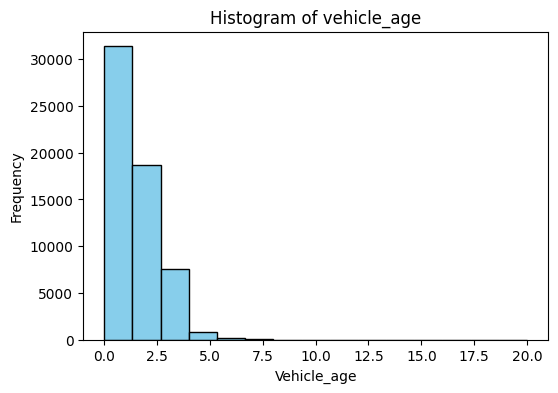

In [9]:
age = 'vehicle_age'
plt.figure(figsize=(6,4))
plt.hist(df[age], bins=15, color='skyblue', edgecolor='black')
plt.title(f'Histogram of {age}') 
plt.xlabel('Vehicle_age')  # X-axis label
plt.ylabel('Frequency')  # Y-axis label
plt.show()

In [10]:
print(a := df['customer_age'].tolist())
data = np.array(a)
print("mean = ", np.mean(data))
print("median = ", np.median(data))
print('mode = ', stats.mode(data).mode)
print('count = ', stats.mode(data).count)
print('Q1 =', np.quantile(data,[0.25]))
print('Q2 =', np.quantile(data,[0.5]))
print('Q3 =', np.quantile(data,[0.75]))
print("standard deviation = ",np.std(data))
#print("Q1 (25th percentile) = ", np.percentile(data, 25))
#print("Median (50th percentile) = ", np.percentile(data, 50))
#print("Q3 (75th percentile) = ", np.percentile(data, 75))

[41, 35, 44, 44, 56, 36, 38, 56, 55, 45, 37, 39, 41, 44, 36, 40, 40, 62, 42, 43, 48, 45, 41, 36, 53, 46, 44, 51, 37, 41, 44, 45, 43, 41, 38, 36, 40, 37, 44, 35, 38, 61, 39, 44, 50, 35, 35, 49, 35, 36, 47, 53, 39, 47, 52, 52, 42, 48, 44, 47, 41, 49, 43, 46, 40, 52, 44, 37, 57, 36, 37, 45, 36, 52, 37, 52, 41, 43, 40, 40, 40, 57, 40, 49, 53, 53, 58, 53, 53, 40, 45, 40, 43, 40, 39, 45, 41, 52, 57, 55, 35, 40, 43, 40, 44, 60, 54, 57, 35, 47, 45, 45, 41, 38, 36, 40, 51, 40, 39, 48, 56, 36, 44, 41, 57, 45, 55, 39, 45, 36, 44, 41, 44, 36, 51, 36, 42, 38, 35, 39, 53, 47, 36, 44, 43, 40, 40, 48, 38, 47, 43, 39, 57, 48, 42, 53, 43, 51, 41, 51, 45, 48, 45, 35, 40, 43, 44, 37, 35, 37, 54, 36, 54, 39, 50, 48, 41, 38, 39, 54, 42, 46, 35, 45, 50, 60, 49, 35, 44, 50, 52, 45, 48, 44, 40, 51, 43, 43, 38, 46, 47, 39, 38, 52, 35, 47, 44, 36, 54, 43, 51, 60, 39, 39, 41, 45, 47, 45, 54, 59, 44, 40, 42, 47, 45, 41, 43, 35, 45, 37, 46, 43, 48, 41, 42, 42, 37, 49, 36, 50, 48, 49, 49, 40, 46, 52, 44, 39, 40, 40,

In [11]:
from scipy import stats
print(b := df['subscription_length'].tolist())
data = np.array(b)
print("mean = ", np.mean(data))
print("median = ", np.median(data))
#model = stats.mode(data)
print('mode = ', stats.mode(data).mode)
print('count = ', stats.mode(data).count)
print('Q1 =', np.quantile(data,[0.25]))
print('Q2 =', np.quantile(data,[0.5]))
print('Q3 =', np.quantile(data,[0.75]))
print("standard deviation = ",np.std(data))

[9.3, 8.2, 9.5, 5.2, 10.1, 3.1, 4.5, 10.7, 10.7, 0.3, 10.5, 5.3, 10.2, 1.4, 5.6, 10.3, 8.8, 0.7, 2.4, 9.7, 11.6, 5.3, 10.2, 0.9, 1.2, 1.3, 12.4, 6.8, 0.7, 10.9, 12.4, 7.7, 8.3, 0.8, 10.6, 2.8, 0.2, 11.8, 6.4, 4.3, 12.1, 5.5, 2.6, 0.9, 10.1, 1.8, 4.6, 2.7, 10.9, 0.9, 2.2, 0.4, 11.7, 10.6, 12.2, 0.8, 3.8, 0.5, 5.0, 1.3, 2.0, 0.6, 1.0, 0.2, 1.1, 4.9, 1.5, 2.8, 11.2, 12.4, 1.0, 8.2, 4.3, 1.8, 11.1, 5.0, 12.2, 10.6, 0.2, 12.3, 1.1, 11.1, 10.7, 6.8, 1.1, 11.8, 8.5, 0.1, 5.3, 0.4, 3.1, 7.4, 4.4, 7.7, 2.1, 3.8, 2.2, 9.7, 7.6, 11.7, 0.9, 5.1, 1.0, 5.7, 0.9, 8.8, 0.8, 3.4, 0.2, 0.4, 5.6, 2.7, 3.8, 3.2, 11.1, 2.2, 1.4, 8.1, 1.1, 3.0, 8.7, 6.5, 2.8, 2.2, 12.2, 10.4, 12.2, 10.3, 9.2, 10.5, 9.6, 0.1, 6.8, 2.8, 10.8, 9.8, 5.7, 10.8, 6.4, 1.6, 11.6, 3.8, 10.4, 3.8, 3.5, 11.8, 10.3, 11.9, 6.4, 0.0, 8.6, 0.4, 2.4, 10.9, 5.4, 9.0, 10.1, 8.7, 6.6, 10.3, 8.6, 0.9, 12.3, 1.3, 6.3, 2.4, 0.4, 10.2, 6.6, 5.8, 5.4, 5.5, 11.2, 0.1, 7.1, 0.3, 2.9, 0.4, 11.3, 11.1, 3.6, 0.4, 0.8, 10.8, 4.3, 11.3, 10.0, 0.9, 10.1, 

In [12]:
print(c := df['vehicle_age'].tolist())
datas = np.array(c)
print("mean = ", np.mean(datas))
print("median = ", np.median(datas))
print('mode = ', stats.mode(datas).mode)
print('count = ', stats.mode(datas).count)
print('Q1 =', np.quantile(datas,[0.25]))
print('Q2 =', np.quantile(datas,[0.5]))
print('Q3 =', np.quantile(datas,[0.75]))
print("standard deviation = ",np.std(datas))

[1.2, 1.8, 0.2, 0.4, 1.0, 2.0, 2.4, 2.0, 0.6, 2.4, 3.0, 1.2, 1.6, 0.0, 0.2, 3.8, 0.4, 0.6, 2.8, 1.0, 0.4, 0.8, 1.0, 1.4, 0.2, 0.0, 2.0, 1.4, 0.0, 2.0, 0.6, 0.0, 1.2, 0.6, 0.8, 1.2, 1.4, 2.0, 2.2, 2.0, 3.8, 0.6, 0.4, 2.2, 2.8, 1.0, 1.2, 0.0, 2.0, 0.4, 3.2, 0.4, 1.2, 3.6, 3.2, 1.4, 2.0, 2.0, 1.4, 3.2, 2.6, 0.0, 0.4, 0.2, 0.4, 1.4, 1.0, 0.2, 0.4, 2.0, 1.2, 0.2, 2.0, 1.6, 1.4, 1.4, 0.4, 1.6, 1.0, 3.2, 1.0, 1.0, 2.2, 0.6, 0.0, 1.6, 0.2, 0.0, 0.4, 2.6, 2.6, 0.2, 0.4, 0.8, 0.4, 0.6, 2.4, 6.0, 1.2, 1.4, 3.0, 0.2, 1.6, 0.0, 3.6, 2.6, 0.0, 0.2, 2.8, 0.4, 0.6, 0.2, 1.8, 0.8, 2.8, 2.4, 0.8, 1.8, 1.0, 2.4, 0.8, 0.4, 2.4, 0.2, 3.0, 0.4, 2.2, 0.2, 2.2, 1.0, 0.4, 0.8, 0.2, 1.4, 0.6, 0.0, 1.0, 1.4, 1.4, 2.8, 0.4, 0.6, 0.2, 2.0, 3.2, 1.0, 2.4, 1.6, 0.4, 0.8, 0.2, 0.2, 0.6, 1.8, 0.2, 0.8, 2.8, 0.0, 0.2, 1.2, 0.8, 2.2, 1.8, 0.4, 1.0, 1.2, 0.6, 0.0, 2.4, 1.8, 0.2, 1.6, 0.4, 1.0, 1.6, 1.4, 2.0, 0.0, 2.2, 2.0, 0.4, 0.2, 2.4, 1.6, 0.2, 0.6, 2.4, 0.8, 0.2, 0.6, 3.6, 2.6, 3.2, 1.0, 1.6, 2.4, 1.8, 0.8, 1.6, 2.0,

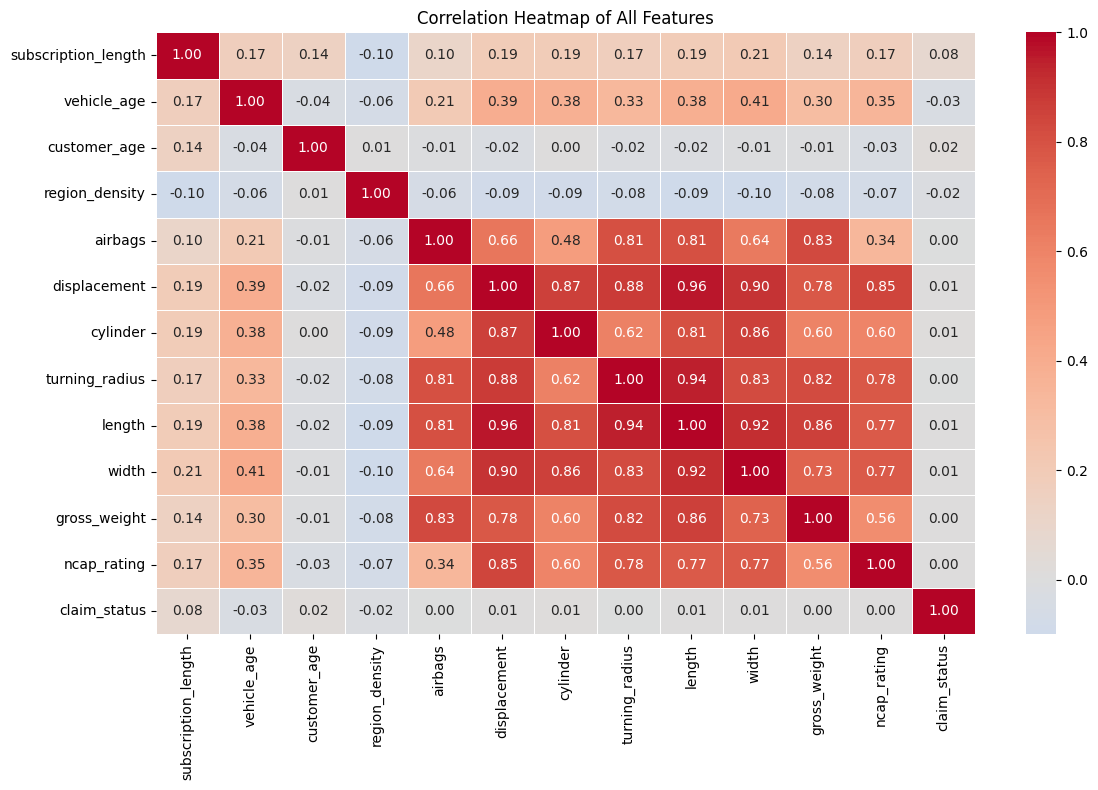

In [13]:
# Correlation heatmap of all numeric features
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.show()

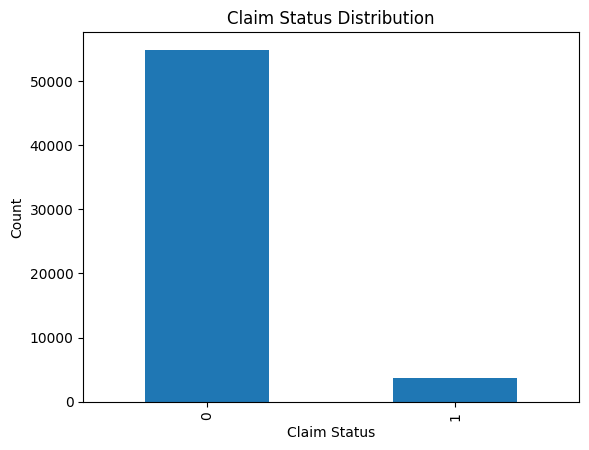

In [14]:
df['claim_status'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Claim Status')
plt.ylabel('Count')
plt.title('Claim Status Distribution')
plt.show()

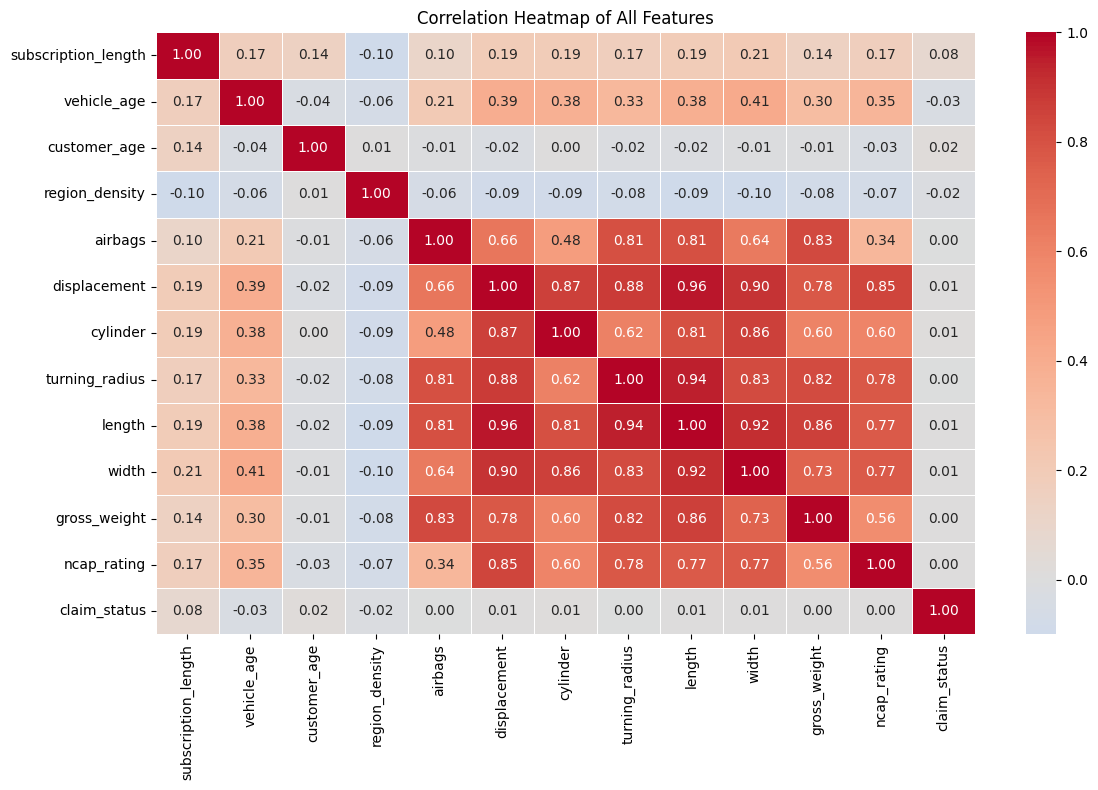

In [15]:
# Correlation heatmap of all numeric features
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.show()

In [16]:
catagorical_features = df.select_dtypes(include= 'object')
print(catagorical_features)


       policy_id region_code segment model fuel_type     max_torque  \
0      POL045360          C8      C2    M4    Diesel  250Nm@2750rpm   
1      POL016745          C2      C1    M9    Diesel  200Nm@1750rpm   
2      POL007194          C8      C2    M4    Diesel  250Nm@2750rpm   
3      POL018146         C10       A    M1       CNG   60Nm@3500rpm   
4      POL049011         C13      B2    M5    Diesel  200Nm@3000rpm   
...          ...         ...     ...   ...       ...            ...   
58587  POL019269          C5      B2    M6    Petrol  113Nm@4400rpm   
58588  POL001254          C3      C2    M4    Diesel  250Nm@2750rpm   
58589  POL019859          C8      B2    M6    Petrol  113Nm@4400rpm   
58590  POL014061          C8      B2    M6    Petrol  113Nm@4400rpm   
58591  POL054184         C12      B2    M6    Petrol  113Nm@4400rpm   

               max_power                engine_type is_esc  \
0      113.45bhp@4000rpm              1.5 L U2 CRDi    Yes   
1       97.89bhp@3600rp

In [17]:
numerical_features = df.select_dtypes(exclude= 'object')
print(numerical_features)

       subscription_length  vehicle_age  customer_age  region_density  \
0                      9.3          1.2            41            8794   
1                      8.2          1.8            35           27003   
2                      9.5          0.2            44            8794   
3                      5.2          0.4            44           73430   
4                     10.1          1.0            56            5410   
...                    ...          ...           ...             ...   
58587                 10.6          2.6            48           34738   
58588                  2.3          2.2            37            4076   
58589                  6.6          2.2            35            8794   
58590                  4.1          3.6            44            8794   
58591                  3.1          0.4            49           34791   

       airbags  displacement  cylinder  turning_radius  length  width  \
0            6          1493         4            